# 🧠 Session 08 — Neural Networks: Handwritten Digit Recognition

---

## 🎯 Goal
Build a **Neural Network** that can look at an image of a handwritten digit and correctly identify **which number (0–9)** it is.

This is a classic **multi-class classification** problem — we are assigning each image to one of 10 categories.

---

## 🗺️ Roadmap
We will follow these steps:
1. Import the tools (libraries)
2. Load and explore the dataset
3. Preprocess the data
4. Build the neural network model
5. Train the model
6. Visualize learning curves
7. Evaluate the model on test data

---

## 📦 The Dataset: MNIST
We will use the famous **MNIST** dataset:
- **70,000 grayscale images** of handwritten digits (0–9)
- Each image is **28 × 28 pixels**
- 60,000 images for **training** and 10,000 for **testing**

> Think of each image as a grid of 784 tiny squares, each holding a brightness value from 0 (black) to 255 (white).

---
## Step 1 — Import Libraries

Before we do anything, we need to bring in the tools we'll use throughout the notebook.

In [1]:
# TensorFlow is the main deep learning framework we use
import tensorflow as tf

# Keras is a high-level API built on top of TensorFlow
# It makes building neural networks much simpler
from tensorflow import keras

# Matplotlib is used for plotting graphs and displaying images
import matplotlib.pyplot as plt

# NumPy is used for fast numerical computations on arrays
import numpy as np

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.19.0


---
## Step 2 — Load and Explore the Dataset

Keras has the MNIST dataset built-in — we just call one function to download and load it.

The dataset comes pre-split into:
- **Training set** — used to teach the model
- **Test set** — used to evaluate the model on unseen data

In [2]:
# Load the MNIST dataset directly from Keras
# It returns two tuples: (training data, training labels) and (test data, test labels)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Let's check the shape of our data
# Shape = (number of samples, height, width)
print("📐 Data Shapes:")
print(f"  X_train : {X_train.shape}  → 60,000 training images, each 28×28 pixels")
print(f"  y_train : {y_train.shape}  → 60,000 labels (the correct digit for each image)")
print(f"  X_test  : {X_test.shape}   → 10,000 test images")
print(f"  y_test  : {y_test.shape}   → 10,000 test labels")

# Check what classes (digits) exist in the training labels
print(f"\n🔢 Unique digit classes: {np.unique(y_train)}")

📐 Data Shapes:
  X_train : (60000, 28, 28)  → 60,000 training images, each 28×28 pixels
  y_train : (60000,)  → 60,000 labels (the correct digit for each image)
  X_test  : (10000, 28, 28)   → 10,000 test images
  y_test  : (10000,)   → 10,000 test labels

🔢 Unique digit classes: [0 1 2 3 4 5 6 7 8 9]


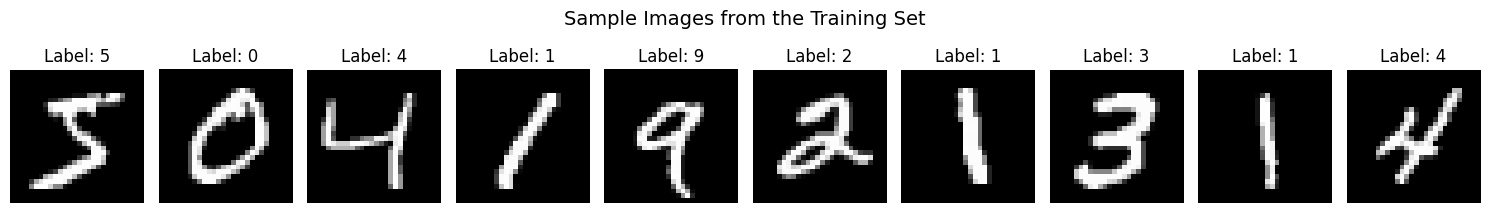


🎨 Pixel value range: min=0, max=255
   (0 = black, 255 = white)


In [3]:
# Let's visualize the first 10 images in the training set
# This helps us understand what the model will be learning from

fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    axes[i].imshow(X_train[i], cmap='gray')   # Display each image in grayscale
    axes[i].set_title(f"Label: {y_train[i]}") # Show the correct label above each image
    axes[i].axis('off')                        # Remove axes for cleaner look

plt.suptitle("Sample Images from the Training Set", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Also peek at pixel value range
print(f"\n🎨 Pixel value range: min={X_train.min()}, max={X_train.max()}")
print("   (0 = black, 255 = white)")

---
## Step 3 — Data Preprocessing

Before feeding data into a neural network, we need to **normalize** the pixel values.

### Why normalize?
- Raw pixel values are in the range **[0, 255]**
- Neural networks train much better when input values are small, ideally in **[0, 1]**
- We simply divide every pixel by 255 to scale it down

> **Analogy:** Imagine grading students on a scale of 0–100 vs 0–1. The math works the same, but small numbers are easier for the network to handle.

In [4]:
# Step 3a: Convert data type to float32
# Neural networks work with decimal numbers (floats), not integers
# float32 uses less memory than float64 and is standard for deep learning
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

# Step 3b: Normalize pixel values from [0, 255] → [0.0, 1.0]
# We divide by 255 because that's the maximum pixel value
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Verify the normalization worked
print("✅ Normalization complete!")
print(f"   Pixel value range after normalization: min={X_train.min():.1f}, max={X_train.max():.1f}")

✅ Normalization complete!
   Pixel value range after normalization: min=0.0, max=1.0


---
## Step 4 — Build the Neural Network Model

We'll use a **Sequential** model — layers stacked one after another like a pipeline.

### Our Architecture:
```
Input: 28×28 image
       ↓
   Flatten  →  converts 28×28 grid into a flat list of 784 numbers
       ↓
  Dense(128) →  128 neurons, each learns different features
       ↓
  Dense(64)  →  64 neurons
       ↓
  Dense(32)  →  32 neurons
       ↓
  Dense(10)  →  10 output neurons, one per digit class (0–9)
```

### Activation Functions:
- **ReLU** (Rectified Linear Unit): Used in hidden layers. Outputs the input if positive, else 0. Helps the network learn non-linear patterns.
- **Softmax**: Used in the final layer. Converts raw scores into **probabilities** that sum to 1.0. The highest probability = predicted class.

In [5]:
from keras.models import Sequential

# Build the model layer by layer
model = Sequential([

    # Layer 1: Input — define the shape of one input sample
    # Each image is 28×28 pixels
    keras.layers.InputLayer(shape=(28, 28)),

    # Layer 2: Flatten — reshape 2D image (28×28) into a 1D vector (784,)
    # Dense layers require 1D input, not 2D grids
    keras.layers.Flatten(),

    # Layer 3: First hidden Dense layer — 128 neurons with ReLU activation
    # Each neuron learns to detect a different pattern in the input
    keras.layers.Dense(128, activation='relu'),

    # Layer 4: Second hidden Dense layer — 64 neurons
    # Progressively smaller layers help the network compress and abstract features
    keras.layers.Dense(64, activation='relu'),

    # Layer 5: Third hidden Dense layer — 32 neurons
    keras.layers.Dense(32, activation='relu'),

    # Layer 6: Output layer — 10 neurons (one for each digit 0–9)
    # Softmax converts the scores into probabilities that sum to 1
    # The neuron with the highest probability is the predicted digit
    keras.layers.Dense(10, activation='softmax'),
])

# Display a summary of the model architecture
# Shows each layer, its output shape, and number of trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 5 — Compile the Model

Before training, we must **compile** the model by specifying:

| Setting | Choice | Why |
|---|---|---|
| **Optimizer** | Adam | Adapts the learning rate automatically — fast and reliable |
| **Loss function** | Sparse Categorical Crossentropy | Standard for multi-class classification when labels are integers |
| **Metric** | Accuracy | Easy to interpret — % of correctly predicted samples |

In [6]:
# Compile the model — this sets up the training process
model.compile(
    optimizer='adam',                          # Adam optimizer: adjusts weights efficiently
    loss='sparse_categorical_crossentropy',    # Loss for integer class labels (0, 1, 2, ...)
    metrics=['accuracy']                       # Track accuracy during training
)

print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


---
## Step 6 — Train the Model

This is where the model actually **learns** from the data.

### Key Parameters:
- **epochs** — how many times the model sees the entire training dataset
- **batch_size** — instead of learning from all 60,000 images at once, we feed 32 at a time (faster and more stable)
- **validation_split** — we hold out 10% of training data to monitor performance on unseen data during training

> Each **epoch** = one full pass through all training batches.

In [7]:
# Train the model on the training data
model_history = model.fit(
    X_train, y_train,          # Training images and their true labels
    validation_split=0.1,      # Use 10% of training data for validation (not for learning)
    batch_size=32,             # Process 32 images at a time before updating weights
    epochs=10                  # Repeat the full training process 10 times
)

# model_history stores the accuracy and loss values after each epoch
# We'll use it to plot learning curves next
print("\n✅ Training complete!")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8579 - loss: 0.4712 - val_accuracy: 0.9647 - val_loss: 0.1201
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9635 - loss: 0.1163 - val_accuracy: 0.9695 - val_loss: 0.0949
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9768 - loss: 0.0737 - val_accuracy: 0.9673 - val_loss: 0.1068
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0587 - val_accuracy: 0.9723 - val_loss: 0.0958
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0463 - val_accuracy: 0.9770 - val_loss: 0.0739
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0383 - val_accuracy: 0.9780 - val_loss: 0.0872
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9893 - loss: 0.0332 - val_accuracy: 0.9762 - val_loss: 0.0925
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0236 - 

---
## Step 7 — Plot Learning Curves

Learning curves show how the model improved over time during training.

### What to look for:
- **Accuracy** should increase over epochs ✅
- **Loss** should decrease over epochs ✅
- If **validation** lines diverge badly from **training** lines → the model may be **overfitting** ⚠️

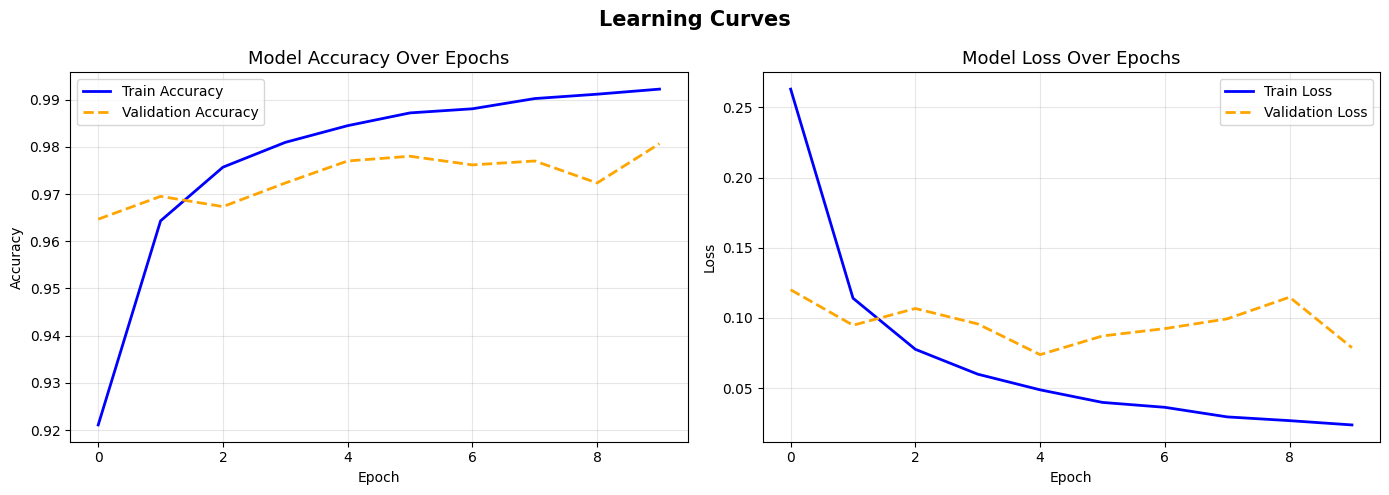

In [8]:
# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy ---
ax1.plot(model_history.history['accuracy'],     label='Train Accuracy',      color='blue',   linewidth=2)
ax1.plot(model_history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy Over Epochs', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
ax2.plot(model_history.history['loss'],     label='Train Loss',      color='blue',   linewidth=2)
ax2.plot(model_history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax2.set_title('Model Loss Over Epochs', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Learning Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8 — Evaluate the Model on Test Data

Training accuracy is not enough — we must test on **data the model has never seen** before.

The test set (10,000 images) was never used during training, so this gives us a fair measurement of real-world performance.

In [9]:
# Evaluate the model on the test set
# Returns: [loss value, accuracy value]
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\n📊 Test Results:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9728 - loss: 0.1131

📊 Test Results:
   Test Loss     : 0.0977
   Test Accuracy : 97.73%


---
## Step 9 — Make Predictions

`model.predict()` returns a **probability distribution** over the 10 classes for each image.

For example: `[0.01, 0.02, 0.90, 0.03, ...]` → the model is 90% confident the digit is **2**.

We use `np.argmax()` to find the index (class) with the highest probability.

In [10]:
# Get raw probability predictions for all test images
# prediction[i] = array of 10 probabilities (one per digit class) for image i
prediction = model.predict(X_test)

print(f"Shape of predictions: {prediction.shape}")
print(f"  → {prediction.shape[0]} images, each with {prediction.shape[1]} class probabilities")

# Show the raw probability output for the first test image
print(f"\nExample — Probabilities for the first test image:")
for digit, prob in enumerate(prediction[0]):
    bar = '█' * int(prob * 30)
    print(f"  Digit {digit}: {prob:.4f}  {bar}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape of predictions: (10000, 10)
  → 10000 images, each with 10 class probabilities

Example — Probabilities for the first test image:
  Digit 0: 0.0000  
  Digit 1: 0.0000  
  Digit 2: 0.0000  
  Digit 3: 0.0000  
  Digit 4: 0.0000  
  Digit 5: 0.0000  
  Digit 6: 0.0000  
  Digit 7: 1.0000  ██████████████████████████████
  Digit 8: 0.0000  
  Digit 9: 0.0000  


In [11]:
# Convert probabilities to final predicted class labels
# np.argmax finds the index of the highest value in each row
classes = np.argmax(prediction, axis=1)
# axis=1 means: find the max across columns (across the 10 probabilities) for each row (each image)

print("First 20 predicted labels:", classes[:20])
print("First 20 true labels:     ", y_test[:20])

# Count how many images were predicted as each digit
unique, counts = np.unique(classes, return_counts=True)
print("\n📊 Prediction distribution across all 10,000 test images:")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} predictions")

First 20 predicted labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 true labels:      [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]

📊 Prediction distribution across all 10,000 test images:
  Digit 0: 998 predictions
  Digit 1: 1133 predictions
  Digit 2: 1025 predictions
  Digit 3: 1034 predictions
  Digit 4: 987 predictions
  Digit 5: 867 predictions
  Digit 6: 963 predictions
  Digit 7: 1055 predictions
  Digit 8: 969 predictions
  Digit 9: 969 predictions


---
## Step 10 — Confusion Matrix & Classification Report

### Confusion Matrix
A table showing **how many predictions fell into each category**:
- Rows = **true** labels
- Columns = **predicted** labels
- Diagonal = **correct** predictions ✅
- Off-diagonal = **mistakes** ❌

### Classification Report
For each digit class, reports:
- **Precision** — of all times I predicted "3", how often was I right?
- **Recall** — of all actual "3"s in the data, how many did I catch?
- **F1-score** — harmonic mean of precision and recall (single combined metric)

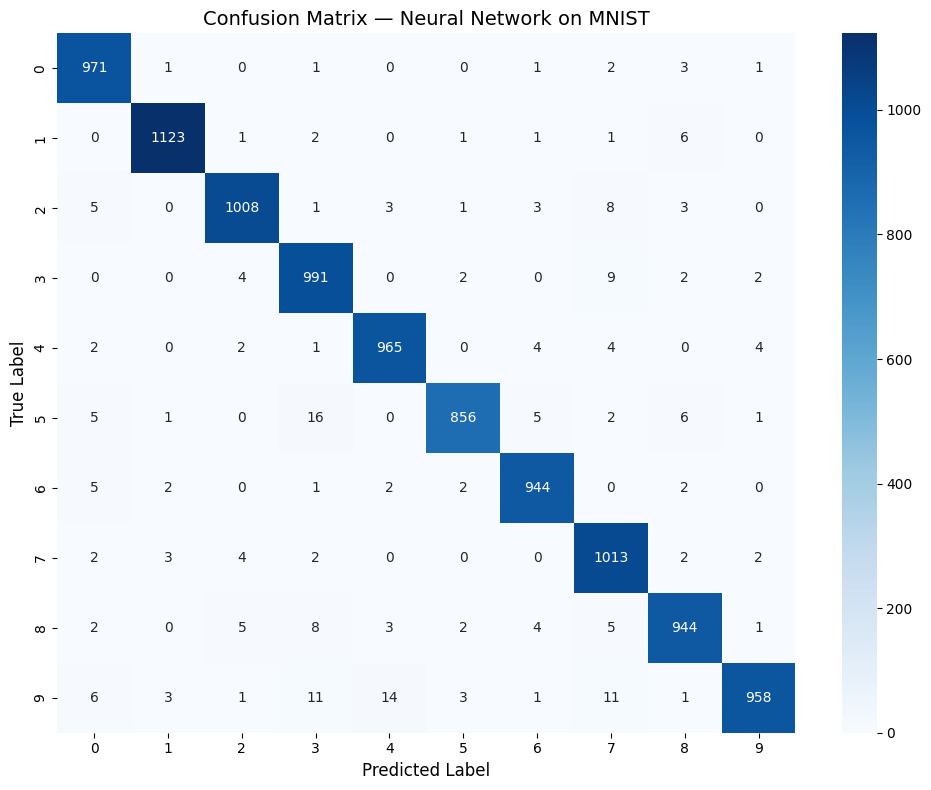

💡 Tip: Large numbers on the diagonal = model is correct.
   Numbers off the diagonal = mistakes (e.g., predicted 7 when the true digit was 1)


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # Optional: for a nicer confusion matrix heatmap

# Compute the confusion matrix
# y_test = true labels, classes = our model's predicted labels
cm = confusion_matrix(y_test, classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,         # Show numbers inside each cell
    fmt='d',            # Format as integer
    cmap='Blues',       # Color scheme
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — Neural Network on MNIST', fontsize=14)
plt.tight_layout()
plt.show()

# Interpretation hint
print("💡 Tip: Large numbers on the diagonal = model is correct.")
print("   Numbers off the diagonal = mistakes (e.g., predicted 7 when the true digit was 1)")

In [13]:
# Print the full classification report
# Shows precision, recall, and F1-score for each digit class
print("📋 Classification Report:\n")
print(classification_report(y_test, classes, digits=3))

# Quick interpretation:
# - precision = when the model says 'X', how often is it right?
# - recall    = out of all actual 'X' images, how many did the model find?
# - f1-score  = balance between precision and recall (higher is better)
# - support   = number of true instances of that digit in the test set

📋 Classification Report:

              precision    recall  f1-score   support

           0      0.973     0.991     0.982       980
           1      0.991     0.989     0.990      1135
           2      0.983     0.977     0.980      1032
           3      0.958     0.981     0.970      1010
           4      0.978     0.983     0.980       982
           5      0.987     0.960     0.973       892
           6      0.980     0.985     0.983       958
           7      0.960     0.985     0.973      1028
           8      0.974     0.969     0.972       974
           9      0.989     0.949     0.969      1009

    accuracy                          0.977     10000
   macro avg      0.977     0.977     0.977     10000
weighted avg      0.977     0.977     0.977     10000



---
## Step 11 — Visualize Predictions (Bonus)

Let's look at some individual predictions to see what the model got right and wrong.

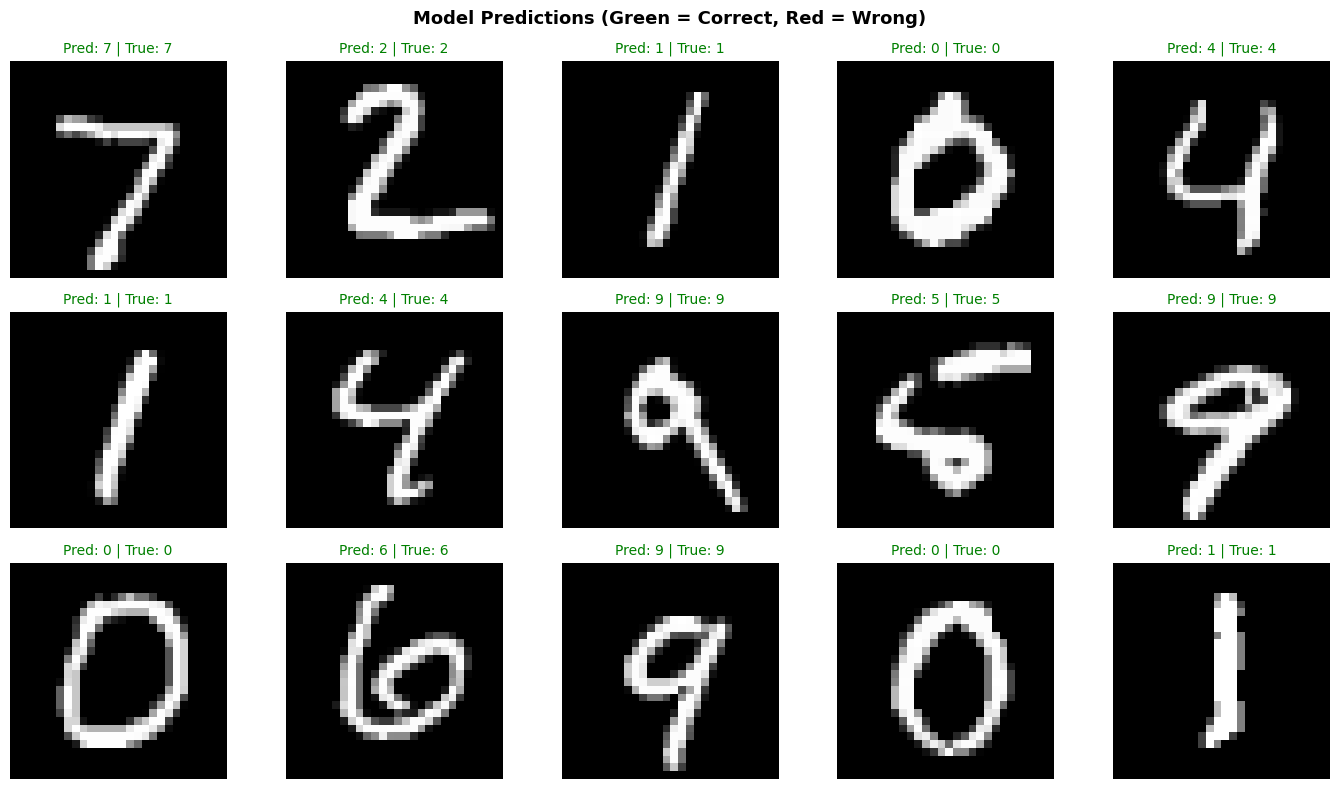

In [14]:
# Display 15 test images with their predicted vs true labels
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
axes = axes.flatten()

for i in range(15):
    axes[i].imshow(X_test[i], cmap='gray')    # Show the image
    predicted = classes[i]                    # What the model predicted
    true_label = y_test[i]                    # The correct answer

    # Color the title green if correct, red if wrong
    color = 'green' if predicted == true_label else 'red'
    axes[i].set_title(f"Pred: {predicted} | True: {true_label}", color=color, fontsize=10)
    axes[i].axis('off')  # Hide axis ticks for cleaner display

plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏁 Summary

Congratulations! You've built a complete neural network pipeline from scratch.

| Step | What We Did |
|------|-------------|
| 1 | Imported TensorFlow, Keras, Matplotlib, NumPy |
| 2 | Loaded and explored the MNIST dataset |
| 3 | Normalized pixel values to [0, 1] |
| 4 | Built a 4-layer Sequential neural network |
| 5 | Compiled with Adam optimizer + cross-entropy loss |
| 6 | Trained for 10 epochs with mini-batches of 32 |
| 7 | Plotted accuracy and loss learning curves |
| 8 | Evaluated on 10,000 unseen test images |
| 9 | Converted probabilities to predicted class labels |
| 10 | Analyzed errors using confusion matrix and report |

### 💡 Key Takeaways
- Neural networks learn by **adjusting weights** to minimize loss
- **Normalization** is crucial — always scale your inputs
- **Softmax** gives probabilities; use `argmax` to get the predicted class
- The **confusion matrix** reveals which digits the model confuses most often

---
*Try experimenting: add more layers, change the number of neurons, or increase epochs. How does it affect accuracy?*